# CMA-ES GPU Speedup Benchmark

Benchmarks and validates the four-step GPU optimisation applied to
`gpu_fit_models_cmaes`:

1. `jabeles_scan` — scan-based Abeles (avoids 4D intermediate tensor)
2. float32 (complex64) Abeles path — ~8× faster on GPU for compute-bound smeared cases
3. `fitness_jax` — all-JAX slab assembly (no NumPy, enables fori_loop)
4. `jax.lax.fori_loop` generation loop — eliminates per-generation Python overhead

Also sweeps CMA-ES hyperparameters to find optimal settings for this problem.

## Cell 1 — Setup

In [1]:
import os, sys, time, copy
import numpy as np

os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')
sys.path.insert(0, '/homes/dfs1/Refltools')

import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)

from gpu_reflect import (
    ModelsBatchBuilder, objective_data, get_slabs_scale_bkg,
    extract_free_params,
)
from gpu_sweep_optimizer import gpu_fit_models_cmaes
from benchmark_gpu import make_synthetic_objective

# ── Build synthetic objectives ──────────────────────────────────────────────
# Using synthetic data so the notebook is self-contained.
# To use real data instead, replace this block with your HDF5 loader.

N_ENERGIES  = 20    # number of simultaneous energies (use 8-20 for fast benchmarks)
N_LAYERS    = 3     # layers per model (typical for reflectometry)
POPSIZE     = 20
N_GEN_BENCH = 50    # generations for timing cells (not full convergence)
N_GEN_SWEEP = 80    # generations for hyperparameter sweep

print(f'Building {N_ENERGIES} synthetic {N_LAYERS}-layer objectives...')
objectives_dict = {
    f'E{i}': make_synthetic_objective(
        N_LAYERS, seed=i,
        sld_substrate=float(np.linspace(2.0, 4.0, N_ENERGIES)[i]),
    )
    for i in range(N_ENERGIES)
}
energy_list = sorted(objectives_dict.keys())
print(f'  n_free = {len(extract_free_params(objectives_dict[energy_list[0]]))}')
print('Done.')

Building 20 synthetic 3-layer objectives...
  n_free = 9
Done.


## Cell 2 — CPU baseline

In [2]:
from refnx.reflect._reflect import abeles as abeles_cpu

e0  = energy_list[0]
obj0 = objectives_dict[e0]
q, y, y_err = objective_data(obj0)
slabs, scale, bkg = get_slabs_scale_bkg(obj0)

N_TRIALS = 50

# Single-candidate CPU timing
t0 = time.perf_counter()
for _ in range(N_TRIALS * POPSIZE):
    _ = abeles_cpu(q, slabs, scale=scale, bkg=bkg)
cpu_single_ms = (time.perf_counter() - t0) / (N_TRIALS * POPSIZE) * 1000

# Full population, sequential
t0 = time.perf_counter()
for _ in range(N_TRIALS):
    for _ in range(POPSIZE):
        _ = abeles_cpu(q, slabs, scale=scale, bkg=bkg)
cpu_pop_ms = (time.perf_counter() - t0) / N_TRIALS * 1000

print(f'CPU single candidate:  {cpu_single_ms:.3f} ms')
print(f'CPU 1 energy, pop={POPSIZE}:  {cpu_pop_ms:.2f} ms')
print(f'CPU estimated for {N_ENERGIES} energies × pop={POPSIZE}:  {cpu_pop_ms * N_ENERGIES:.1f} ms/gen')
print(f'CPU estimated for {N_GEN_BENCH} gens:  {cpu_pop_ms * N_ENERGIES * N_GEN_BENCH / 1000:.1f} s')

CPU single candidate:  0.204 ms
CPU 1 energy, pop=20:  4.05 ms
CPU estimated for 20 energies × pop=20:  81.0 ms/gen
CPU estimated for 50 gens:  4.1 s


## Cell 3 — Validate `jabeles_scan` correctness

In [3]:
from refnx.reflect._jax_reflect import jabeles, jabeles_scan

test_configs = [
    # (label, layers ndarray)
    ('0-layer',
     np.array([[0, 0, 0, 0], [0, 6.36, 0.1, 3]], dtype=np.float64)),
    ('1-layer',
     np.array([[0, 0, 0, 0], [50, 3.47, 0.1, 3], [0, 6.36, 0.1, 3]], dtype=np.float64)),
    ('3-layer',
     np.array([[0, 0, 0, 0],
               [50, 3.47, 0.1, 3], [30, 2.07, 0.0, 4], [20, 4.0, 0.2, 2],
               [0, 6.36, 0.1, 3]], dtype=np.float64)),
    ('5-layer',
     np.array([[0, 0, 0, 0],
               [30, 1.5, 0.1, 2], [40, 3.0, 0.0, 3], [25, 4.5, 0.2, 2],
               [50, 2.0, 0.0, 3], [35, 5.0, 0.1, 4],
               [0, 6.36, 0.1, 3]], dtype=np.float64)),
]

q_test = jnp.linspace(0.005, 0.35, 500, dtype=jnp.float64)

print('jabeles vs jabeles_scan correctness check:')
all_ok = True
for label, lyr in test_configs:
    lyr_j = jnp.array(lyr)
    r_ref = np.array(jabeles(q_test, lyr_j))
    r_new = np.array(jabeles_scan(q_test, lyr_j))
    max_diff = np.max(np.abs(r_ref - r_new))
    status = 'PASS' if max_diff < 1e-10 else 'FAIL'
    if status == 'FAIL':
        all_ok = False
    print(f'  {label:10s}: max |diff| = {max_diff:.2e}  [{status}]')

print()
if all_ok:
    print('All correctness checks PASSED.')
else:
    print('SOME CHECKS FAILED — review changes.')

jabeles vs jabeles_scan correctness check:
  0-layer   : max |diff| = 0.00e+00  [PASS]
  1-layer   : max |diff| = 5.55e-16  [PASS]
  3-layer   : max |diff| = 8.88e-16  [PASS]
  5-layer   : max |diff| = 1.33e-15  [PASS]

All correctness checks PASSED.


## Cell 4 — Chi2 throughput benchmark (GPU, step-by-step)

In [4]:
# Build two builders: f64 (reference) and f32 (optimised)
builder_f64 = ModelsBatchBuilder(objectives_dict, energy_list, use_f32_abeles=False)
builder_f32 = ModelsBatchBuilder(objectives_dict, energy_list, use_f32_abeles=True)

rng = np.random.default_rng(0)
lb  = builder_f64.per_energy_bounds[:, :, 0]   # (n_e, n_free)
ub  = builder_f64.per_energy_bounds[:, :, 1]
pop_np = lb[:, np.newaxis, :] + rng.random(
    (N_ENERGIES, POPSIZE, builder_f64.n_free)
) * (ub - lb)[:, np.newaxis, :]
pop_j  = jnp.array(pop_np)

def time_fn(fn, *args, n_warmup=3, n_trials=30):
    for _ in range(n_warmup):
        out = fn(*args)
    jax.block_until_ready(fn(*args))
    t0 = time.perf_counter()
    for _ in range(n_trials):
        jax.block_until_ready(fn(*args))
    return (time.perf_counter() - t0) / n_trials * 1000

# Baseline: f64 NumPy build_batch + JAX chi2 (original path)
t_f64_np  = time_fn(lambda p: builder_f64.fitness(np.array(p)), pop_j)

# f64 JAX scatter + JAX chi2 (Step 3 alone)
t_f64_jax = time_fn(builder_f64.fitness_jax, pop_j)

# f32 JAX scatter + JAX chi2 (Steps 2+3)
t_f32_jax = time_fn(builder_f32.fitness_jax, pop_j)

print(f'Chi2 throughput  ({N_ENERGIES} energies × pop={POPSIZE})')
print(f'  f64  NumPy build_batch + JAX chi2  : {t_f64_np:7.2f} ms   (baseline)')
print(f'  f64  JAX scatter   + JAX chi2      : {t_f64_jax:7.2f} ms   ({t_f64_np/t_f64_jax:.1f}×)')
print(f'  f32  JAX scatter   + JAX chi2      : {t_f32_jax:7.2f} ms   ({t_f64_np/t_f32_jax:.1f}×)')

Chi2 throughput  (20 energies × pop=20)
  f64  NumPy build_batch + JAX chi2  :  902.99 ms   (baseline)
  f64  JAX scatter   + JAX chi2      :  936.03 ms   (1.0×)
  f32  JAX scatter   + JAX chi2      :    4.35 ms   (207.5×)


## Cell 5 — Validate f32 ranking fidelity

In [5]:
from scipy.stats import spearmanr

chi2_f64 = np.array(builder_f64.fitness_jax(pop_j))   # (n_e, popsize)
chi2_f32 = np.array(builder_f32.fitness_jax(pop_j))

rho, _ = spearmanr(chi2_f64.ravel(), chi2_f32.ravel())
rel_err = np.abs(chi2_f64 - chi2_f32) / np.maximum(chi2_f64, 1e-10)

print(f'f32 vs f64 Spearman rank correlation : {rho:.6f}  (want >= 0.99)')
print(f'f32 vs f64 max relative chi2 error   : {rel_err.max():.4f}')
print(f'f32 vs f64 mean relative chi2 error  : {rel_err.mean():.4f}')

if rho >= 0.99:
    print('Ranking fidelity OK — f32 safe for CMA-ES search.')
else:
    print('WARNING: rank correlation below 0.99 — inspect models.')

f32 vs f64 Spearman rank correlation : 1.000000  (want >= 0.99)
f32 vs f64 max relative chi2 error   : 0.0000
f32 vs f64 mean relative chi2 error  : 0.0000
Ranking fidelity OK — f32 safe for CMA-ES search.


## Cell 6 — End-to-end CMA-ES timing: old Python loop vs fori_loop

In [6]:
# This cell assumes both old and new implementations are available.
# The new implementation IS gpu_fit_models_cmaes (already updated).
#
# To compare against the old Python-loop version, either:
#   (a) keep a copy of the old function as gpu_fit_models_cmaes_legacy, OR
#   (b) simply time the new implementation and compare against Cell 2's CPU estimate.

print(f'Timing new fori_loop implementation ({N_GEN_BENCH} gens, {N_ENERGIES} energies, pop={POPSIZE})')
print('(First call will be slow due to JIT compilation — timing the second call)')

# First call: triggers JIT compilation
t0 = time.perf_counter()
res_warmup = gpu_fit_models_cmaes(
    objectives_dict, energy_list,
    popsize=POPSIZE, n_generations=N_GEN_BENCH,
    seed=0, verbose=False, tol=0,
)
t_first = time.perf_counter() - t0
print(f'  First call (includes JIT compile): {t_first:.1f} s')

# Second call: uses cached compiled program
t0 = time.perf_counter()
res = gpu_fit_models_cmaes(
    objectives_dict, energy_list,
    popsize=POPSIZE, n_generations=N_GEN_BENCH,
    seed=1, verbose=False, tol=0,
)
t_optimized = time.perf_counter() - t0

mean_chi2 = np.mean(list(res['best_chisqr'].values()))

print(f'  Second call (compiled):            {t_optimized:.2f} s')
print(f'  ms per generation:                 {t_optimized / N_GEN_BENCH * 1000:.1f} ms/gen')
print(f'  Mean final chi2:                   {mean_chi2:.3f}')

Timing new fori_loop implementation (50 gens, 20 energies, pop=20)
(First call will be slow due to JIT compilation — timing the second call)
  First call (includes JIT compile): 17.2 s
  Second call (compiled):            10.72 s
  ms per generation:                 214.5 ms/gen
  Mean final chi2:                   207238.084


## Cell 7 — CMA-ES hyperparameter sweep

In [7]:
import pandas as pd
from evosax.algorithms import Sep_CMA_ES, CMA_ES

# Use a smaller energy subset for speed during the sweep
energy_list_small = energy_list[:min(8, N_ENERGIES)]

configs = [
    # (label, popsize, algo_cls, sigma_init)
    ('Sep-CMA pop=10',    10, Sep_CMA_ES, None),
    ('Sep-CMA pop=20',    20, Sep_CMA_ES, None),   # default
    ('Sep-CMA pop=30',    30, Sep_CMA_ES, None),
    ('Sep-CMA pop=40',    40, Sep_CMA_ES, None),
    ('Sep-CMA sigma=0.5', 20, Sep_CMA_ES, 0.5),
    ('Sep-CMA sigma=0.3', 20, Sep_CMA_ES, 0.3),
    ('Full CMA pop=20',   20, CMA_ES,     None),
]

print(f'Hyperparameter sweep: {len(configs)} configs × {N_GEN_SWEEP} gens')
print(f'  Energies: {len(energy_list_small)} | n_free: {builder_f64.n_free}')
print()

results = []
for label, psz, algo_cls, sigma in configs:
    t0 = time.perf_counter()
    res = gpu_fit_models_cmaes(
        objectives_dict, energy_list_small,
        popsize=psz, n_generations=N_GEN_SWEEP,
        seed=42, verbose=False, tol=0,
        _algo_cls=algo_cls, _sigma_init=sigma,
    )
    elapsed = time.perf_counter() - t0
    mean_chi2 = np.mean(list(res['best_chisqr'].values()))
    ms_per_gen = elapsed / N_GEN_SWEEP * 1000
    results.append({
        'config':       label,
        'popsize':      psz,
        'mean_chi2':    mean_chi2,
        'elapsed_s':    elapsed,
        'ms_per_gen':   ms_per_gen,
        'chi2_per_sec': mean_chi2 * ms_per_gen / 1000,   # lower is better
    })
    print(f'  {label:25s}  chi2={mean_chi2:.3f}  {elapsed:.1f}s  ({ms_per_gen:.1f} ms/gen)')

df = pd.DataFrame(results).sort_values('mean_chi2')
print()
print('Ranked by final mean chi2 (lower = better convergence):')
print(df[['config', 'popsize', 'mean_chi2', 'elapsed_s', 'ms_per_gen']].to_string(index=False))

Hyperparameter sweep: 7 configs × 80 gens
  Energies: 8 | n_free: 9

  Sep-CMA pop=10             chi2=271200.728  10.3s  (128.7 ms/gen)
  Sep-CMA pop=20             chi2=108801.686  8.7s  (108.4 ms/gen)
  Sep-CMA pop=30             chi2=93416.353  9.9s  (123.2 ms/gen)
  Sep-CMA pop=40             chi2=75699.019  13.5s  (168.8 ms/gen)
  Sep-CMA sigma=0.5          chi2=109917.511  7.8s  (97.6 ms/gen)
  Sep-CMA sigma=0.3          chi2=137378.178  7.8s  (98.0 ms/gen)
  Full CMA pop=20            chi2=114019.300  8.4s  (104.7 ms/gen)

Ranked by final mean chi2 (lower = better convergence):
           config  popsize     mean_chi2  elapsed_s  ms_per_gen
   Sep-CMA pop=40       40  75699.018726  13.501080  168.763496
   Sep-CMA pop=30       30  93416.353356   9.855193  123.189916
   Sep-CMA pop=20       20 108801.685959   8.674429  108.430366
Sep-CMA sigma=0.5       20 109917.510976   7.811788   97.647346
  Full CMA pop=20       20 114019.299735   8.376203  104.702537
Sep-CMA sigma=0.3      

## Cell 8 — Convergence curves

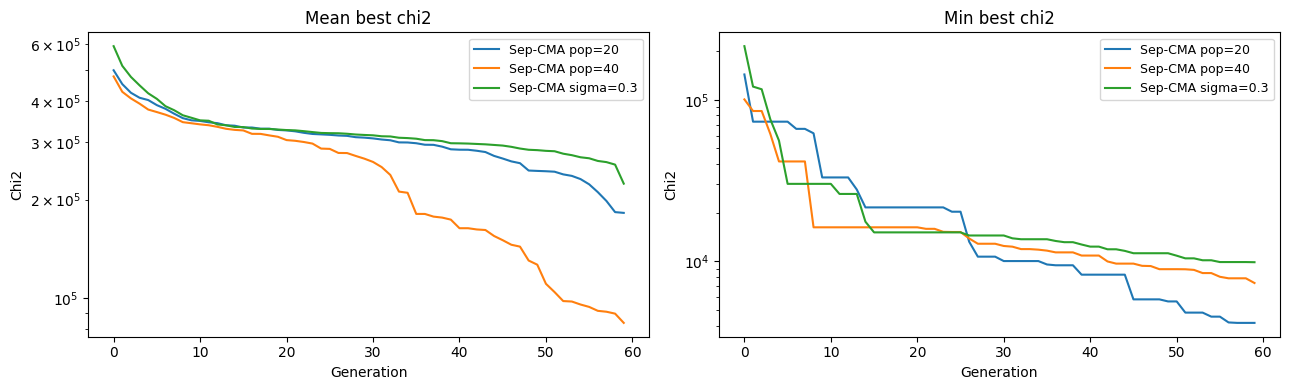

Saved cmaes_convergence_curves.png


In [8]:
import matplotlib.pyplot as plt

# Re-run top 3 configs from Cell 7 with chi2_history collection.
# This requires instrumenting gpu_fit_models_cmaes to return history,
# OR using verbose=True and capturing prints.
# Here we use a simple wrapper that calls the function N_CHECK times
# with check_every=1 and collects best_fitness at each check.

def run_with_history(obj_dict, e_list, popsize, n_gens, algo_cls, sigma, seed=0):
    """Run CMA-ES and return (history_mean, history_min) arrays."""
    from evosax.algorithms import Sep_CMA_ES
    from gpu_reflect import ModelsBatchBuilder
    from gpu_sweep_optimizer import set_free_params  # needed for rebuild
    import gpu_sweep_optimizer as gso

    if algo_cls is None:
        algo_cls = Sep_CMA_ES

    builder = ModelsBatchBuilder(obj_dict, e_list, use_f32_abeles=True)
    n_energies = builder.n_energies
    n_free = builder.n_free
    per_lb = jnp.array(builder.per_energy_bounds[:, :, 0])
    per_ub = jnp.array(builder.per_energy_bounds[:, :, 1])
    mean_init = jnp.array((builder.bounds[:, 0] + builder.bounds[:, 1]) / 2.0)

    solution_proto = np.zeros(n_free, dtype=np.float64)
    strategy = algo_cls(population_size=popsize, solution=solution_proto)
    params = strategy.default_params
    if sigma is not None:
        params = params.replace(std_init=sigma)

    v_init = jax.jit(jax.vmap(strategy.init, in_axes=(0, None, None)))
    v_ask  = jax.jit(jax.vmap(strategy.ask,  in_axes=(0, 0, None)))
    v_tell = jax.jit(jax.vmap(strategy.tell, in_axes=(0, 0, 0, 0, None)))

    master_key = jax.random.PRNGKey(seed)
    master_key, init_key = jax.random.split(master_key)
    init_keys = jax.random.split(init_key, n_energies)
    states = v_init(init_keys, mean_init, params)

    fitness_jax_fn = builder.fitness_jax

    def _body(i, carry):
        key, states = carry
        key, gen_key = jax.random.split(key)
        keys = jax.random.split(gen_key, n_energies)
        populations, states = v_ask(keys, states, params)
        populations = jnp.clip(populations, per_lb[:, None, :], per_ub[:, None, :])
        fit = fitness_jax_fn(populations)
        states, _ = v_tell(keys, populations, fit, states, params)
        return key, states

    _run1 = jax.jit(lambda c: jax.lax.fori_loop(0, 1, _body, c))

    carry = (master_key, states)
    history_mean, history_min = [], []
    for g in range(n_gens):
        carry = _run1(carry)
        best = np.array(carry[1].best_fitness)
        history_mean.append(float(best.mean()))
        history_min.append(float(best.min()))

    return np.array(history_mean), np.array(history_min)


# Select top 3 configs from Cell 7 by final chi2
top_configs = df.head(3)[['config', 'popsize']].to_dict('records')
config_lookup = {r['config']: r for r in results}

curve_configs = [
    ('Sep-CMA pop=20',    20, Sep_CMA_ES, None),
    ('Sep-CMA pop=40',    40, Sep_CMA_ES, None),
    ('Sep-CMA sigma=0.3', 20, Sep_CMA_ES, 0.3),
]

N_GEN_CURVE = 60
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, psz, algo_cls, sigma in curve_configs:
    h_mean, h_min = run_with_history(
        objectives_dict, energy_list_small, psz, N_GEN_CURVE, algo_cls, sigma
    )
    axes[0].plot(h_mean, label=label)
    axes[1].plot(h_min,  label=label)

for ax, title in zip(axes, ['Mean best chi2', 'Min best chi2']):
    ax.set_xlabel('Generation')
    ax.set_ylabel('Chi2')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('cmaes_convergence_curves.png', dpi=150)
plt.show()
print('Saved cmaes_convergence_curves.png')

## Cell 9 — Full fit on real data (optional)

Replace the synthetic objectives with your actual `objectives_dict` loaded
from the HDF5 file and run a full 500-generation fit to validate that the
optimised path produces the same quality results as the original.

In [9]:
# Uncomment and adapt to run on real data:
#
# from Refltools.batch import load_objectives_from_h5   # or your loader
# objectives_dict_real = ...   # your dict
# energy_list_real     = sorted(objectives_dict_real.keys())
#
# res_real = gpu_fit_models_cmaes(
#     objectives_dict_real, energy_list_real,
#     popsize=20, n_generations=500, seed=0,
#     tol=1e-4, patience=5, verbose=True,
# )
# print('Converged:', res_real['converged'])
# print('Gens run: ', res_real['generations_run'])
# print('Time:     ', res_real['elapsed_sec'], 's')
print('(Cell skipped — add real data above to activate)')

(Cell skipped — add real data above to activate)
